In [155]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Current working directory:", os.getcwd())
print("Python version:", sys.version)
print("Libraries imported successfully.")

Current working directory: d:\User\Desktop\CreditCardFraud_AutoEncoder
Python version: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
Libraries imported successfully.


In [156]:
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("report", exist_ok=True)

print("Project folders are ready.")

Project folders are ready.


In [157]:
data_path = "data/creditcard.csv"

print("File exists:", os.path.exists(data_path))
print("Absolute path:", os.path.abspath(data_path))

File exists: True
Absolute path: d:\User\Desktop\CreditCardFraud_AutoEncoder\data\creditcard.csv


In [158]:
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [159]:
df.info()
print("Total missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [160]:
class_counts = df["Class"].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

normal_count = class_counts[0]
fraud_count = class_counts[1]
fraud_ratio = fraud_count / len(df) * 100

print("\nNormal transactions:", normal_count)
print("Fraud transactions:", fraud_count)
print("Fraud ratio: {:.4f}%".format(fraud_ratio))

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Normal transactions: 284315
Fraud transactions: 492
Fraud ratio: 0.1727%


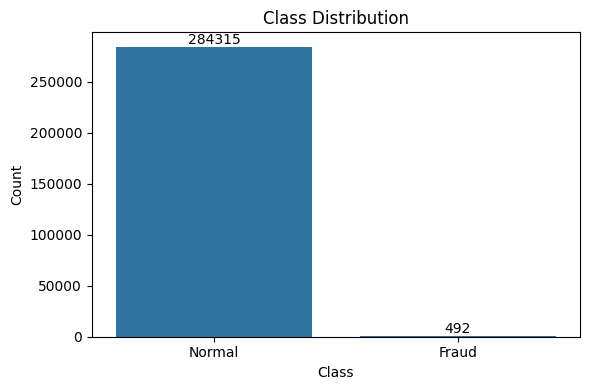

In [161]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Normal", "Fraud"])

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=300)
plt.show()

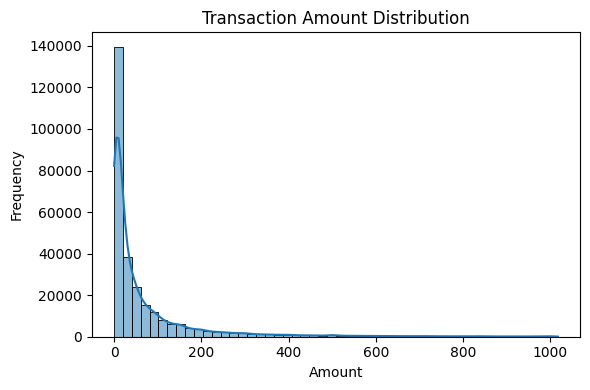

99% amount limit: 1017.9700000000012


In [162]:
amount_limit = df["Amount"].quantile(0.99)

plt.figure(figsize=(6, 4))
sns.histplot(df[df["Amount"] <= amount_limit]["Amount"], bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("figures/amount_distribution.png", dpi=300)
plt.show()

print("99% amount limit:", amount_limit)

feature_summary = pd.DataFrame({
    "字段": ["Time", "V1-V28", "Amount", "Class"],
    "含义": [
        "交易发生的相对时间",
        "经过 PCA 处理后的匿名交易特征",
        "交易金额",
        "交易类别标签，0 表示正常交易，1 表示欺诈交易"
    ],
    "是否用于模型": [
        "否，本文实验中删除该字段",
        "是",
        "是，经过标准化后使用",
        "否，作为监督评价标签"
    ]
})

feature_summary

In [163]:
sample_rows = pd.concat([
    df[df["Class"] == 0].head(3),
    df[df["Class"] == 1].head(3)
])

sample_rows[["Time", "V1", "V2", "V3", "Amount", "Class"]]

,Time,V1,V2,V3,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,149.62,0
1,0.0,1.191857,0.266151,0.166480,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,378.66,0
541,406.0,-2.312227,1.951992,-1.609851,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,239.93,1


In [164]:
summary_text = f"""
Dataset shape: {df.shape}
Total missing values: {df.isnull().sum().sum()}
Normal transactions: {normal_count}
Fraud transactions: {fraud_count}
Fraud ratio: {fraud_ratio:.4f}%
Amount 99% quantile: {amount_limit:.2f}
"""

with open("results/data_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print(summary_text)
print("Data summary saved to results/data_summary.txt")


Dataset shape: (284807, 31)
Total missing values: 0
Normal transactions: 284315
Fraud transactions: 492
Fraud ratio: 0.1727%
Amount 99% quantile: 1017.97

Data summary saved to results/data_summary.txt


In [165]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader

# 固定随机种子，保证实验结果可复现
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [166]:
# 删除 Time 字段，保留 V1-V28 和 Amount 作为模型输入
X = df.drop(columns=["Time", "Class"])

# Class 是标签，0 表示正常交易，1 表示欺诈交易
y = df["Class"].astype(int)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)
print("Input features:", list(X.columns))

Feature shape: (284807, 29)
Label shape: (284807,)
Input features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [167]:
# 第一次划分：85% 临时训练集 + 15% 测试集
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y
)

# 第二次划分：从 85% 临时训练集中划出 15% 作为验证集
val_ratio = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (199364, 29)
Validation shape: (42721, 29)
Test shape: (42722, 29)


In [168]:
def show_class_distribution(name, labels):
    counts = labels.value_counts().sort_index()
    total = len(labels)
    normal = counts.get(0, 0)
    fraud = counts.get(1, 0)
    fraud_ratio = fraud / total * 100
    
    print(f"{name}:")
    print(f"  Total: {total}")
    print(f"  Normal: {normal}")
    print(f"  Fraud: {fraud}")
    print(f"  Fraud ratio: {fraud_ratio:.4f}%")
    print()

show_class_distribution("Training set", y_train)
show_class_distribution("Validation set", y_val)
show_class_distribution("Test set", y_test)

Training set:
  Total: 199364
  Normal: 199020
  Fraud: 344
  Fraud ratio: 0.1725%

Validation set:
  Total: 42721
  Normal: 42647
  Fraud: 74
  Fraud ratio: 0.1732%

Test set:
  Total: 42722
  Normal: 42648
  Fraud: 74
  Fraud ratio: 0.1732%



In [169]:
scaler = StandardScaler()

# 只在训练集上拟合标准化器
X_train_scaled = scaler.fit_transform(X_train)

# 验证集和测试集只做 transform
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled validation data shape:", X_val_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

Scaled training data shape: (199364, 29)
Scaled validation data shape: (42721, 29)
Scaled test data shape: (42722, 29)


In [170]:
# 自编码器训练时只使用正常交易样本
normal_train_mask = (y_train.values == 0)

X_train_ae = X_train_scaled[normal_train_mask]

print("Original training samples:", X_train_scaled.shape[0])
print("Normal samples used for AutoEncoder training:", X_train_ae.shape[0])
print("Input dimension:", X_train_ae.shape[1])

Original training samples: 199364
Normal samples used for AutoEncoder training: 199020
Input dimension: 29


In [171]:
BATCH_SIZE = 256

X_train_tensor = torch.tensor(X_train_ae, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Number of training batches:", len(train_loader))
print("Batch size:", BATCH_SIZE)

Number of training batches: 778
Batch size: 256


In [172]:
np.savez(
    "results/preprocessed_data.npz",
    X_train_ae=X_train_ae,
    X_val_scaled=X_val_scaled,
    X_test_scaled=X_test_scaled,
    y_val=y_val.values,
    y_test=y_test.values
)

print("Preprocessed data saved to results/preprocessed_data.npz")

Preprocessed data saved to results/preprocessed_data.npz


In [173]:
preprocessing_summary = f"""
Data preprocessing summary

Original dataset shape: {df.shape}
Input features: V1-V28 and Amount
Removed columns: Time, Class
Input dimension: {X_train_ae.shape[1]}

Train set: {X_train.shape[0]} samples
Validation set: {X_val.shape[0]} samples
Test set: {X_test.shape[0]} samples

Normal samples used for AutoEncoder training: {X_train_ae.shape[0]}

Scaling method: StandardScaler
Scaler fitting strategy: fit on training set only, transform validation and test sets
Random seed: {RANDOM_SEED}
Batch size: {BATCH_SIZE}
"""

with open("results/preprocessing_summary.txt", "w", encoding="utf-8") as f:
    f.write(preprocessing_summary)

print(preprocessing_summary)
print("Preprocessing summary saved to results/preprocessing_summary.txt")


Data preprocessing summary

Original dataset shape: (284807, 31)
Input features: V1-V28 and Amount
Removed columns: Time, Class
Input dimension: 29

Train set: 199364 samples
Validation set: 42721 samples
Test set: 42722 samples

Normal samples used for AutoEncoder training: 199020

Scaling method: StandardScaler
Scaler fitting strategy: fit on training set only, transform validation and test sets
Random seed: 42
Batch size: 256

Preprocessing summary saved to results/preprocessing_summary.txt


In [174]:
preprocess_table = pd.DataFrame({
    "步骤": [
        "删除 Time 字段",
        "分离特征与标签",
        "分层划分数据集",
        "标准化处理",
        "筛选正常训练样本",
        "构建 DataLoader"
    ],
    "具体操作": [
        "删除 Time，保留 V1-V28 和 Amount 作为输入特征",
        "X 为交易特征，y 为 Class 标签",
        "按 70% / 15% / 15% 划分训练集、验证集和测试集",
        "使用 StandardScaler 对输入特征进行标准化",
        "仅使用训练集中的正常交易样本训练自编码器",
        "将正常训练样本转换为 PyTorch Tensor 并按 batch 加载"
    ],
    "目的": [
        "减少无关时间字段对模型训练的影响",
        "明确模型输入与评价标签",
        "保持各数据集中的类别比例基本一致",
        "提高神经网络训练稳定性",
        "让模型学习正常交易模式",
        "为后续模型训练做准备"
    ]
})

preprocess_table

,步骤,具体操作,目的
0,删除 Time 字段,删除 Time，保留 V1-V28 和 Amount 作为输入特征,减少无关时间字段对模型训练的影响
1,分离特征与标签,X 为交易特征，y 为 Class 标签,明确模型输入与评价标签
2,分层划分数据集,按 70% / 15% / 15% 划分训练集、验证集和测试集,保持各数据集中的类别比例基本一致
3,标准化处理,使用 StandardScaler 对输入特征进行标准化,提高神经网络训练稳定性
4,筛选正常训练样本,仅使用训练集中的正常交易样本训练自编码器,让模型学习正常交易模式
5,构建 DataLoader,将正常训练样本转换为 PyTorch Tensor 并按 batch 加载,为后续模型训练做准备


In [175]:
import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.12.0+cpu
Using device: cpu


In [176]:
# 验证集中的正常交易样本
normal_val_mask = (y_val.values == 0)
X_val_ae = X_val_scaled[normal_val_mask]

print("Normal validation samples:", X_val_ae.shape[0])
print("Input dimension:", X_val_ae.shape[1])

Normal validation samples: 42647
Input dimension: 29


In [177]:
BATCH_SIZE = 256

X_train_tensor = torch.tensor(X_train_ae, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_ae, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))

Number of training batches: 778
Number of validation batches: 167


In [178]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super(AutoEncoder, self).__init__()
        
        # Encoder: compress input features into a low-dimensional representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # Decoder: reconstruct the original input features
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


input_dim = X_train_ae.shape[1]
model = AutoEncoder(input_dim).to(device)

print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=29, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=29, bias=True)
  )
)


In [179]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 30

print("Loss function: MSELoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", EPOCHS)

Loss function: MSELoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 30


In [180]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_train_loss = 0
    
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.6f} "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch [1/30] Train Loss: 0.496345 Val Loss: 0.249880
Epoch [2/30] Train Loss: 0.177836 Val Loss: 0.119227
Epoch [3/30] Train Loss: 0.101885 Val Loss: 0.091590
Epoch [4/30] Train Loss: 0.084883 Val Loss: 0.080735
Epoch [5/30] Train Loss: 0.076251 Val Loss: 0.071058
Epoch [6/30] Train Loss: 0.069743 Val Loss: 0.065915
Epoch [7/30] Train Loss: 0.064500 Val Loss: 0.064697
Epoch [8/30] Train Loss: 0.061086 Val Loss: 0.058739
Epoch [9/30] Train Loss: 0.058271 Val Loss: 0.057639
Epoch [10/30] Train Loss: 0.054404 Val Loss: 0.053281
Epoch [11/30] Train Loss: 0.052283 Val Loss: 0.051051
Epoch [12/30] Train Loss: 0.050813 Val Loss: 0.053958
Epoch [13/30] Train Loss: 0.048541 Val Loss: 0.050442
Epoch [14/30] Train Loss: 0.047147 Val Loss: 0.048424
Epoch [15/30] Train Loss: 0.046519 Val Loss: 0.045898
Epoch [16/30] Train Loss: 0.045194 Val Loss: 0.045886
Epoch [17/30] Train Loss: 0.044704 Val Loss: 0.044483
Epoch [18/30] Train Loss: 0.043173 Val Loss: 0.043517
Epoch [19/30] Train Loss: 0.043706 Va

In [181]:
loss_history = pd.DataFrame({
    "epoch": range(1, EPOCHS + 1),
    "train_loss": train_losses,
    "val_loss": val_losses
})

loss_history.to_csv("results/loss_history.csv", index=False)

loss_history.head()

,epoch,train_loss,val_loss
0,1,0.496345,0.249880
1,2,0.177836,0.119227
2,3,0.101885,0.091590
3,4,0.084883,0.080735
4,5,0.076251,0.071058


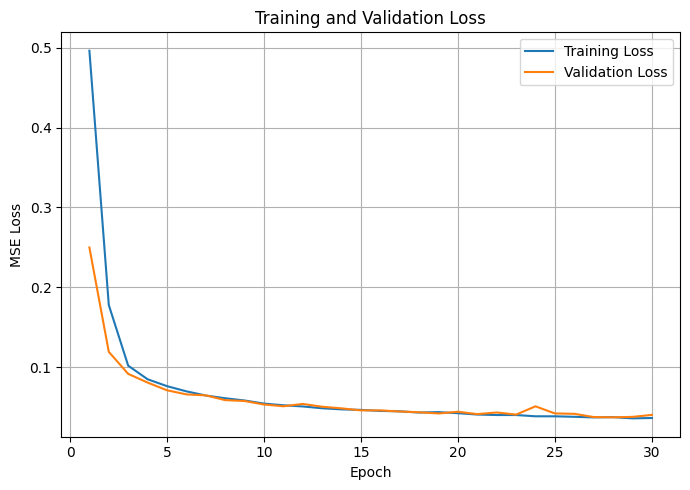

In [182]:
plt.figure(figsize=(7, 5))

plt.plot(loss_history["epoch"], loss_history["train_loss"], label="Training Loss")
plt.plot(loss_history["epoch"], loss_history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figures/loss_curve.png", dpi=300)
plt.show()

In [183]:
torch.save(model.state_dict(), "results/autoencoder_model.pth")

print("Model saved to results/autoencoder_model.pth")

Model saved to results/autoencoder_model.pth


In [184]:
model_summary = f"""
AutoEncoder model summary

Input dimension: {input_dim}
Encoder: {input_dim} -> 64 -> 32 -> 16
Decoder: 16 -> 32 -> 64 -> {input_dim}
Activation function: ReLU
Output layer activation: Linear
Loss function: MSELoss
Optimizer: Adam
Learning rate: 0.001
Batch size: {BATCH_SIZE}
Epochs: {EPOCHS}
Training samples: normal transactions only
Device: {device}
"""

with open("results/model_summary.txt", "w", encoding="utf-8") as f:
    f.write(model_summary)

print(model_summary)


AutoEncoder model summary

Input dimension: 29
Encoder: 29 -> 64 -> 32 -> 16
Decoder: 16 -> 32 -> 64 -> 29
Activation function: ReLU
Output layer activation: Linear
Loss function: MSELoss
Optimizer: Adam
Learning rate: 0.001
Batch size: 256
Epochs: 30
Training samples: normal transactions only
Device: cpu



In [185]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


In [186]:
def compute_reconstruction_errors(model, data, device):
    model.eval()
    
    data_tensor = torch.tensor(data, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        reconstructed = model(data_tensor)
        errors = torch.mean((data_tensor - reconstructed) ** 2, dim=1)
    
    return errors.cpu().numpy()


val_errors = compute_reconstruction_errors(model, X_val_scaled, device)
test_errors = compute_reconstruction_errors(model, X_test_scaled, device)

print("Validation errors shape:", val_errors.shape)
print("Test errors shape:", test_errors.shape)
print("Validation error example:", val_errors[:5])

Validation errors shape: (42721,)
Test errors shape: (42722,)
Validation error example: [0.00195921 0.00705183 0.00117792 0.02459816 0.05127385]


In [187]:
val_errors_normal = val_errors[y_val.values == 0]

threshold = np.percentile(val_errors_normal, 99)

print("Threshold:", threshold)
print("Mean normal validation error:", np.mean(val_errors_normal))
print("Max normal validation error:", np.max(val_errors_normal))

Threshold: 0.4394212
Mean normal validation error: 0.040199522
Max normal validation error: 46.701138


In [188]:
y_test_pred = (test_errors > threshold).astype(int)

print("Prediction finished.")
print("Predicted normal:", np.sum(y_test_pred == 0))
print("Predicted fraud:", np.sum(y_test_pred == 1))

Prediction finished.
Predicted normal: 42264
Predicted fraud: 458


In [189]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, test_errors)
pr_auc = average_precision_score(y_test, test_errors)

print("Test Results")
print("Accuracy: {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall: {:.4f}".format(recall))
print("F1-score: {:.4f}".format(f1))
print("ROC-AUC: {:.4f}".format(roc_auc))
print("PR-AUC: {:.4f}".format(pr_auc))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Fraud"], zero_division=0))

Test Results
Accuracy: 0.9904
Precision: 0.1310
Recall: 0.8108
F1-score: 0.2256
ROC-AUC: 0.9638
PR-AUC: 0.6301

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     42648
       Fraud       0.13      0.81      0.23        74

    accuracy                           0.99     42722
   macro avg       0.57      0.90      0.61     42722
weighted avg       1.00      0.99      0.99     42722



In [190]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc, pr_auc]
})

metrics_df.to_csv("results/test_metrics.csv", index=False)

metrics_df

,Metric,Value
0,Accuracy,0.990356
1,Precision,0.131004
2,Recall,0.810811
3,F1-score,0.225564
4,ROC-AUC,0.963845
5,PR-AUC,0.630147


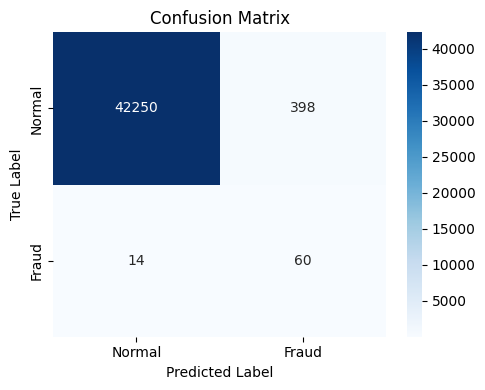

[[42250   398]
 [   14    60]]


In [191]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.show()

print(cm)

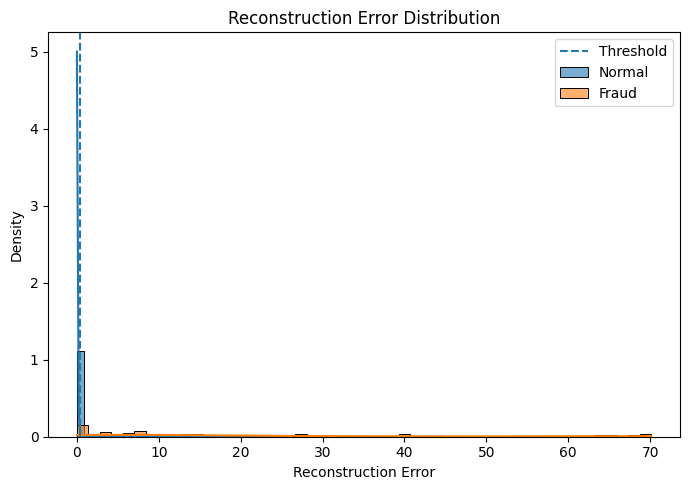

In [192]:
test_errors_normal = test_errors[y_test.values == 0]
test_errors_fraud = test_errors[y_test.values == 1]

plt.figure(figsize=(7, 5))

sns.histplot(test_errors_normal, bins=50, kde=True, stat="density", label="Normal", alpha=0.6)
sns.histplot(test_errors_fraud, bins=50, kde=True, stat="density", label="Fraud", alpha=0.6)

plt.axvline(threshold, linestyle="--", label="Threshold")

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig("figures/reconstruction_error_distribution.png", dpi=300)
plt.show()

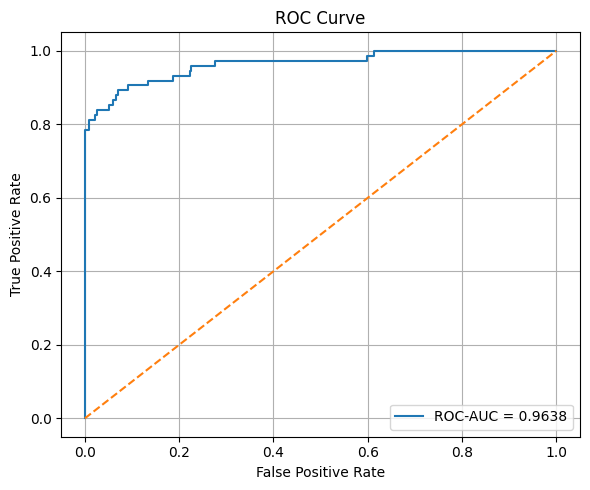

In [193]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_errors)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=300)
plt.show()

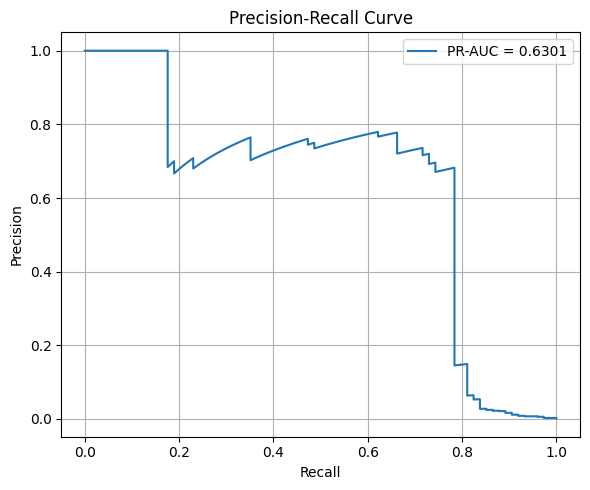

In [194]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, test_errors)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("figures/pr_curve.png", dpi=300)
plt.show()

In [195]:
threshold_results = []

for q in [95, 97, 98, 99, 99.5]:
    temp_threshold = np.percentile(val_errors_normal, q)
    temp_pred = (test_errors > temp_threshold).astype(int)
    
    temp_accuracy = accuracy_score(y_test, temp_pred)
    temp_precision = precision_score(y_test, temp_pred, zero_division=0)
    temp_recall = recall_score(y_test, temp_pred, zero_division=0)
    temp_f1 = f1_score(y_test, temp_pred, zero_division=0)
    
    threshold_results.append({
        "Quantile": q,
        "Threshold": temp_threshold,
        "Accuracy": temp_accuracy,
        "Precision": temp_precision,
        "Recall": temp_recall,
        "F1-score": temp_f1
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df.to_csv("results/threshold_comparison.csv", index=False)

threshold_results_df

,Quantile,Threshold,Accuracy,Precision,Recall,F1-score
0,95.0,0.148974,0.950377,0.028571,0.837838,0.055258
1,97.0,0.210384,0.970109,0.046722,0.837838,0.088508
2,98.0,0.272015,0.980010,0.066667,0.810811,0.123203
3,99.0,0.439421,0.990356,0.131004,0.810811,0.225564
4,99.5,0.705665,0.994710,0.216418,0.783784,0.339181


In [196]:
final_summary = f"""
Final test results

Threshold selection: 99th percentile of normal validation reconstruction errors
Threshold: {threshold:.6f}

Accuracy: {accuracy:.4f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-score: {f1:.4f}
ROC-AUC: {roc_auc:.4f}
PR-AUC: {pr_auc:.4f}

Confusion matrix:
{cm}
"""

with open("results/final_results_summary.txt", "w", encoding="utf-8") as f:
    f.write(final_summary)

print(final_summary)
print("Final results saved to results/final_results_summary.txt")


Final test results

Threshold selection: 99th percentile of normal validation reconstruction errors
Threshold: 0.439421

Accuracy: 0.9904
Precision: 0.1310
Recall: 0.8108
F1-score: 0.2256
ROC-AUC: 0.9638
PR-AUC: 0.6301

Confusion matrix:
[[42250   398]
 [   14    60]]

Final results saved to results/final_results_summary.txt


In [197]:
# Use 99.5th percentile as the final threshold
final_quantile = 99.5
final_threshold = np.percentile(val_errors_normal, final_quantile)

y_test_pred_final = (test_errors > final_threshold).astype(int)

final_accuracy = accuracy_score(y_test, y_test_pred_final)
final_precision = precision_score(y_test, y_test_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_test_pred_final, zero_division=0)
final_f1 = f1_score(y_test, y_test_pred_final, zero_division=0)
final_roc_auc = roc_auc_score(y_test, test_errors)
final_pr_auc = average_precision_score(y_test, test_errors)

final_cm = confusion_matrix(y_test, y_test_pred_final)

print("Final Test Results with 99.5% Threshold")
print("Threshold:", final_threshold)
print("Accuracy: {:.4f}".format(final_accuracy))
print("Precision: {:.4f}".format(final_precision))
print("Recall: {:.4f}".format(final_recall))
print("F1-score: {:.4f}".format(final_f1))
print("ROC-AUC: {:.4f}".format(final_roc_auc))
print("PR-AUC: {:.4f}".format(final_pr_auc))

print("\nConfusion Matrix:")
print(final_cm)

Final Test Results with 99.5% Threshold
Threshold: 0.7056651
Accuracy: 0.9947
Precision: 0.2164
Recall: 0.7838
F1-score: 0.3392
ROC-AUC: 0.9638
PR-AUC: 0.6301

Confusion Matrix:
[[42438   210]
 [   16    58]]


In [198]:
final_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
    "Value": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc
    ]
})

final_metrics_df.to_csv("results/final_test_metrics.csv", index=False)

final_metrics_df

,Metric,Value
0,Accuracy,0.994710
1,Precision,0.216418
2,Recall,0.783784
3,F1-score,0.339181
4,ROC-AUC,0.963845
5,PR-AUC,0.630147


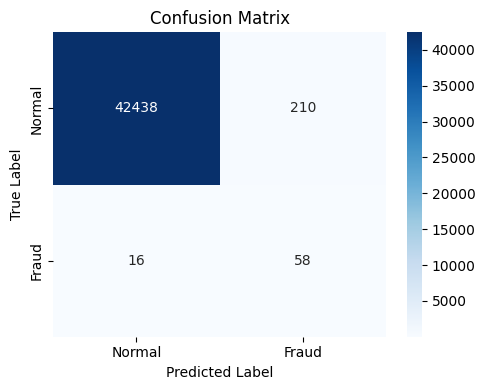

In [199]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("figures/final_confusion_matrix.png", dpi=300)
plt.show()

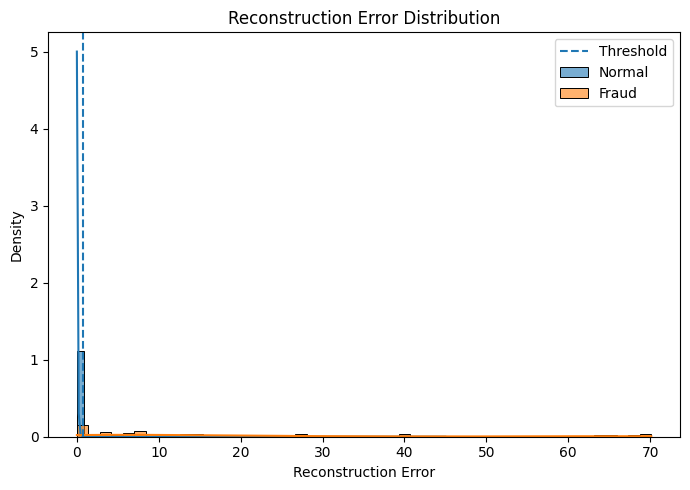

In [200]:
test_errors_normal = test_errors[y_test.values == 0]
test_errors_fraud = test_errors[y_test.values == 1]

plt.figure(figsize=(7, 5))

sns.histplot(
    test_errors_normal,
    bins=50,
    kde=True,
    stat="density",
    label="Normal",
    alpha=0.6
)

sns.histplot(
    test_errors_fraud,
    bins=50,
    kde=True,
    stat="density",
    label="Fraud",
    alpha=0.6
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label="Threshold"
)

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig("figures/final_reconstruction_error_distribution.png", dpi=300)
plt.show()

In [201]:
final_summary = f"""
Final test results

Threshold selection: {final_quantile}th percentile of normal validation reconstruction errors
Threshold: {final_threshold:.6f}

Accuracy: {final_accuracy:.4f}
Precision: {final_precision:.4f}
Recall: {final_recall:.4f}
F1-score: {final_f1:.4f}
ROC-AUC: {final_roc_auc:.4f}
PR-AUC: {final_pr_auc:.4f}

Confusion matrix:
{final_cm}
"""

with open("results/final_results_summary_995.txt", "w", encoding="utf-8") as f:
    f.write(final_summary)

print(final_summary)


Final test results

Threshold selection: 99.5th percentile of normal validation reconstruction errors
Threshold: 0.705665

Accuracy: 0.9947
Precision: 0.2164
Recall: 0.7838
F1-score: 0.3392
ROC-AUC: 0.9638
PR-AUC: 0.6301

Confusion matrix:
[[42438   210]
 [   16    58]]



In [202]:
import platform
import sklearn
import torch
import pandas as pd
import numpy as np
import matplotlib

env_info = {
    "Operating System": platform.platform(),
    "Python": platform.python_version(),
    "PyTorch": torch.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "Device": str(device)
}

env_info

{'Operating System': 'Windows-10-10.0.26100-SP0',
 'Python': '3.10.20',
 'PyTorch': '2.12.0+cpu',
 'pandas': '2.3.3',
 'numpy': '2.2.6',
 'scikit-learn': '1.7.2',
 'matplotlib': '3.10.9',
 'Device': 'cpu'}